In [1]:
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "qnli"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 104743
    })
    validation: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
    test: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['question', 'sentence', 'label', 'idx'],
    num_rows: 104743
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 104743
    })
    validation: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
    test: Dataset({
        features: ['question', 'sentence', 'label', 'idx'],
        num_rows: 5463
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'question': 'When did the third Digimon series begin?',
 'sentence': 'Unlike the two seasons before it and most of the seasons that followed, Digimon Tamers takes a darker and more realistic approach to its story featuring Digimon who do not reincarnate after their deaths and more complex character development in the original Japanese.',
 'label': 1,
 'idx': 0}

In [10]:
raw_train_dataset[5]['question'], raw_train_dataset[5]['sentence']

("When is the term 'German dialects' used in regard to the German language?",
 'When talking about the German language, the term German dialects is only used for the traditional regional varieties.')

In [11]:
raw_train_dataset[5]['label']

0

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'question': Value('string'),
 'sentence': Value('string'),
 'label': ClassLabel(names=['entailment', 'not_entailment']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["question"], example["sentence"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

Map: 100%|██████████| 5463/5463 [00:00<00:00, 27406.24 examples/s]


DatasetDict({
    train: Dataset({
        features: ['question', 'sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 104743
    })
    validation: Dataset({
        features: ['question', 'sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5463
    })
    test: Dataset({
        features: ['question', 'sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5463
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["question", "sentence", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 84]),
 'token_type_ids': torch.Size([32, 84]),
 'attention_mask': torch.Size([32, 84])}

# 4. Loading model

In [19]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [20]:
import sys
sys.path.insert(0, '../')

In [21]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [22]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [23]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True,
    
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [25]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.7970, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [26]:
outputs.keys()

odict_keys(['loss', 'logits', 'hidden_states', 'attentions'])

In [27]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

device

device(type='cuda')

### Loading Trained Weights

In [28]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [29]:
from train_eval_func import eval_loop

In [30]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.9134175361522973}

# 5. Similarity Analysis

In [31]:
from CKA import CKAEvaluator

cka_eval = CKAEvaluator(device)

### Using Training Data

In [32]:
reps_similarity, atts_similarity, sub_similarity = cka_eval.subLayer_interleaved_pairwise(
    model, 
    train_dataloader, 
    device, 
    only_cls_token=True, 
    max_iter=115
)
reps_stats = cka_eval.similarity_stats(reps_similarity)
atts_stats = cka_eval.similarity_stats(atts_similarity)
subs_stats = cka_eval.similarity_stats(sub_similarity)

print("  Reps Similarity Stats:")
print(f"    Average: {reps_stats['average']:.6f}")
print(f"    Highest: {reps_stats['max']:.6f}")
print(f"    Lowest:  {reps_stats['min']:.6f}")
print("")

print("  Atts Similarity Stats:")
print(f"    Average: {atts_stats['average']:.6f}")
print(f"    Highest: {atts_stats['max']:.6f}")
print(f"    Lowest:  {atts_stats['min']:.6f}")

print("  Sublayer Similarity Stats:")
print(f"    Average: {subs_stats['average']:.6f}")
print(f"    Highest: {subs_stats['max']:.6f}")
print(f"    Lowest:  {subs_stats['min']:.6f}")

CKA Sublayer Evaluation: 100%|██████████| 115/115 [00:37<00:00,  3.04it/s]

  Reps Similarity Stats:
    Average: 0.878662
    Highest: 0.959961
    Lowest:  0.701227

  Atts Similarity Stats:
    Average: 0.945501
    Highest: 0.995225
    Lowest:  0.752220
  Sublayer Similarity Stats:
    Average: 0.563553
    Highest: 0.782114
    Lowest:  0.281387


In [33]:
import matplotlib.pyplot as plt
import seaborn as sn

Text(50.722222222222214, 0.5, 'Layer')

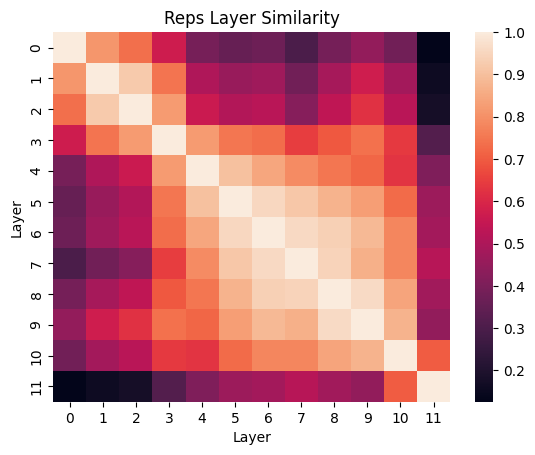

In [34]:
title = "Reps Layer Similarity"
plt.title(title)
sn.heatmap(data = reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

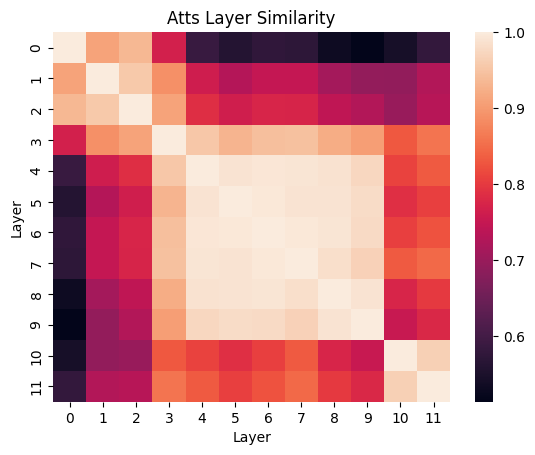

In [35]:
title = "Atts Layer Similarity"
plt.title(title)
sn.heatmap(data = atts_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

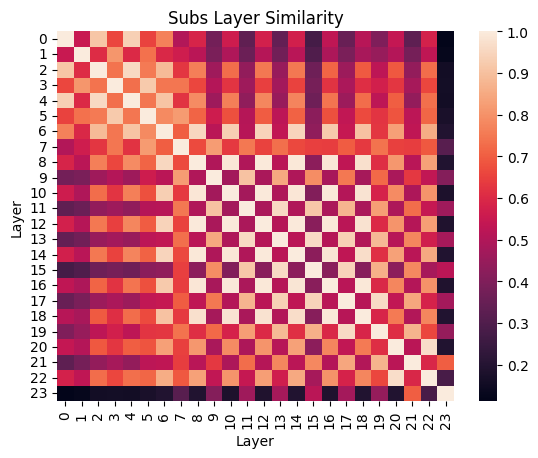

In [36]:
title = "Subs Layer Similarity"
plt.title(title)
sn.heatmap(data = sub_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

### Using Validation Data

In [37]:
reps_similarity, atts_similarity, sub_similarity = cka_eval.subLayer_interleaved_pairwise(
    model, 
    val_dataloader, 
    device, 
    only_cls_token=True, 
    max_iter=115
)
reps_stats = cka_eval.similarity_stats(reps_similarity)
atts_stats = cka_eval.similarity_stats(atts_similarity)
subs_stats = cka_eval.similarity_stats(sub_similarity)

print("  Reps Similarity Stats:")
print(f"    Average: {reps_stats['average']:.6f}")
print(f"    Highest: {reps_stats['max']:.6f}")
print(f"    Lowest:  {reps_stats['min']:.6f}")
print("")

print("  Atts Similarity Stats:")
print(f"    Average: {atts_stats['average']:.6f}")
print(f"    Highest: {atts_stats['max']:.6f}")
print(f"    Lowest:  {atts_stats['min']:.6f}")

print("  Sublayer Similarity Stats:")
print(f"    Average: {subs_stats['average']:.6f}")
print(f"    Highest: {subs_stats['max']:.6f}")
print(f"    Lowest:  {subs_stats['min']:.6f}")

CKA Sublayer Evaluation: 100%|██████████| 115/115 [00:37<00:00,  3.10it/s]

  Reps Similarity Stats:
    Average: 0.878122
    Highest: 0.960509
    Lowest:  0.690520

  Atts Similarity Stats:
    Average: 0.945487
    Highest: 0.995076
    Lowest:  0.753586
  Sublayer Similarity Stats:
    Average: 0.567786
    Highest: 0.778604
    Lowest:  0.286239


In [38]:
import matplotlib.pyplot as plt
import seaborn as sn

Text(50.722222222222214, 0.5, 'Layer')

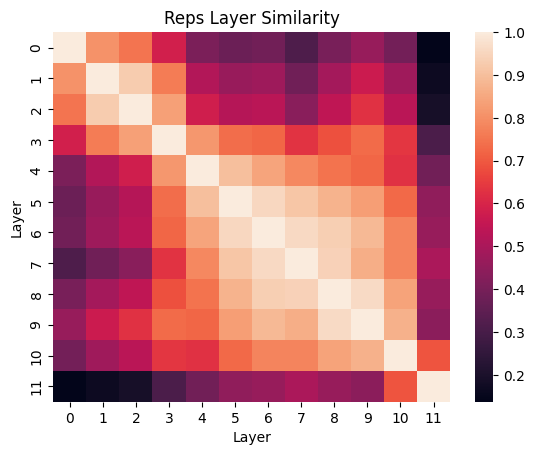

In [39]:
title = "Reps Layer Similarity"
plt.title(title)
sn.heatmap(data = reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

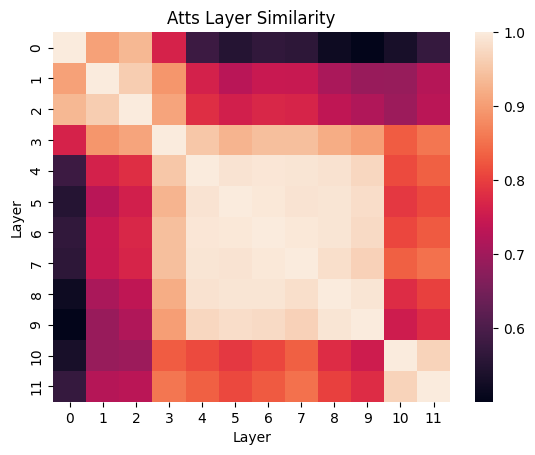

In [40]:
title = "Atts Layer Similarity"
plt.title(title)
sn.heatmap(data = atts_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

Text(50.722222222222214, 0.5, 'Layer')

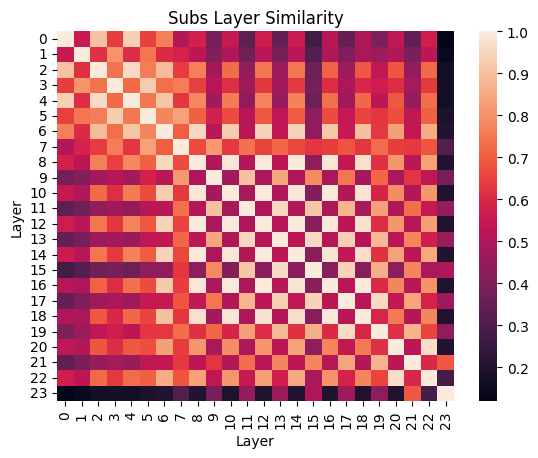

In [41]:
title = "Subs Layer Similarity"
plt.title(title)
sn.heatmap(data = sub_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")